In [1]:
# Imports & Setup
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision
from torchvision import datasets, models, transforms
from torchvision.utils import make_grid
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# Force exactly the same results (no randomness in calculations, algorithms)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration (GPU if available, else CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define data directory (update this to your local path where you unzipped the dataset)
data_dir = 'C:/Root/Projects/Machine_Learning_and_Data_Science/pneumonia-xray-classifier/data'  # e.g., '/Users/yourname/Downloads/chest_xray' or in Colab: '/content/chest_xray'

# data_dir path validation
if not os.path.exists(data_dir):
    raise ValueError(f"Data directory not found: {data_dir}. Please update the path.")
else:
    print(os.listdir(data_dir))

Using device: cuda:0
['test', 'train', 'val']


Class Distribution:
           train  val  test
NORMAL      1341    8   234
PNEUMONIA   3875    8   390


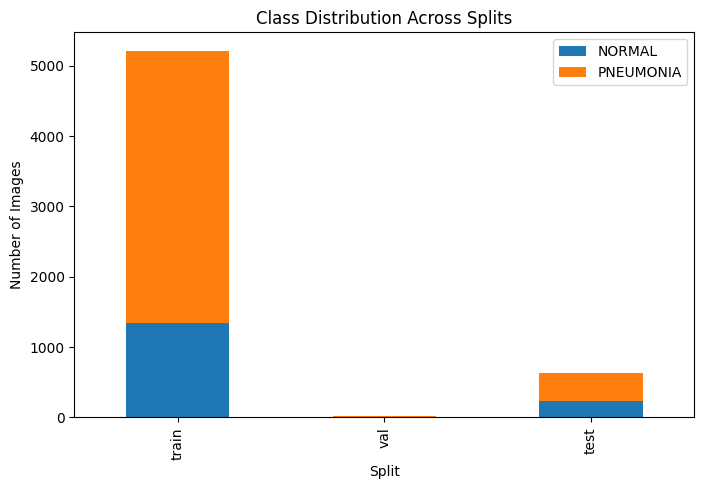

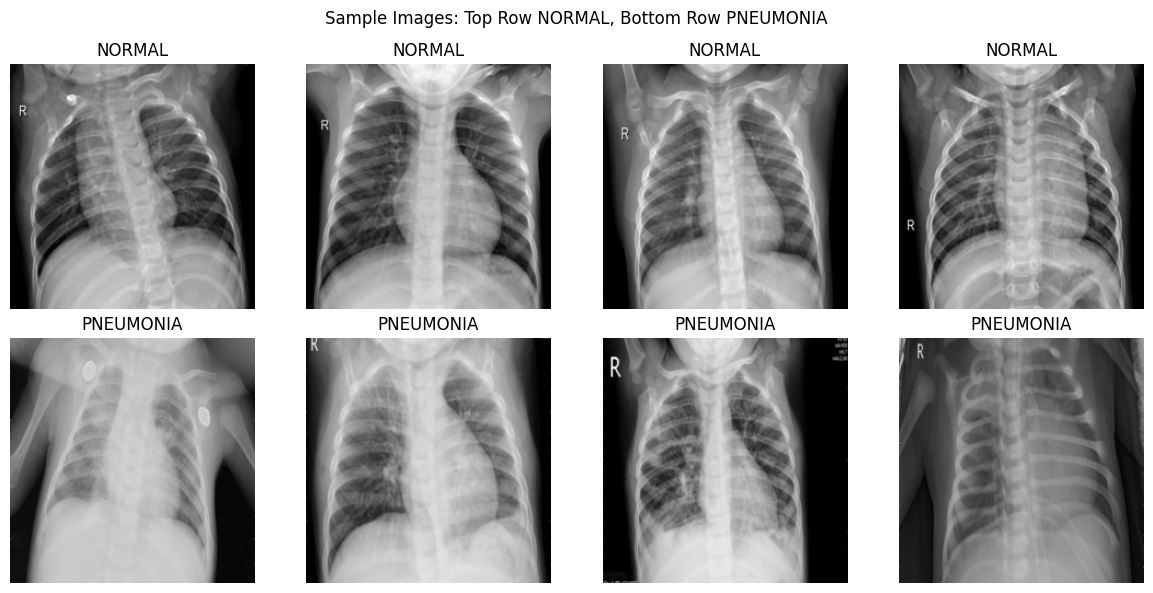

Average Image Size (H x W): 968.07 x 1320.61


In [2]:
# Dataset Exploration / Quick EDA

# Helper function to count images per class
def count_images_per_class(root_dir):
    classes = ['NORMAL', 'PNEUMONIA']
    splits = ['train', 'val', 'test']
    counts = {split: {cls: 0 for cls in classes} for split in splits}
    
    for split in splits:
        split_dir = os.path.join(root_dir, split)
        for cls in classes:
            cls_dir = os.path.join(split_dir, cls)
            if os.path.exists(cls_dir):
                counts[split][cls] = len(os.listdir(cls_dir))
    
    return pd.DataFrame(counts)

# Get class distribution
class_counts = count_images_per_class(data_dir)
print("Class Distribution:")
print(class_counts)

# Visualize class distribution
class_counts.T.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Class Distribution Across Splits')
plt.xlabel('Split')
plt.ylabel('Number of Images')
plt.show()

# Load sample images (raw, no transforms yet)
sample_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Just for display consistency
    transforms.ToTensor()
])

# Quick datasets for samples
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=sample_transform)
class_names = train_dataset.classes  # ['NORMAL', 'PNEUMONIA']

# Function to show samples side-by-side
def show_samples(dataset, num_samples=4):
    fig, axes = plt.subplots(2, num_samples, figsize=(12, 6))
    for i, cls_idx in enumerate([0, 1]):  # One row per class
        class_samples = [idx for idx, label in enumerate(dataset.targets) if label == cls_idx]
        selected = random.sample(class_samples, min(num_samples, len(class_samples)))
        
        for j, idx in enumerate(selected):
            img, label = dataset[idx]
            axes[i, j].imshow(img.permute(1, 2, 0))  # CHW to HWC
            axes[i, j].set_title(class_names[label])
            axes[i, j].axis('off')
    
    plt.suptitle('Sample Images: Top Row NORMAL, Bottom Row PNEUMONIA')
    plt.tight_layout()
    plt.show()

# Show samples from train
show_samples(train_dataset)

# Compute average image size (from raw images)
def get_avg_image_size(root_dir, split='train'):
    sizes = []
    split_dir = os.path.join(root_dir, split)
    for cls in os.listdir(split_dir):
        cls_dir = os.path.join(split_dir, cls)
        for img_file in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_file)
            img = plt.imread(img_path)
            sizes.append(img.shape[:2])  # (H, W)
    
    avg_h = np.mean([s[0] for s in sizes])
    avg_w = np.mean([s[1] for s in sizes])
    return avg_h, avg_w

avg_h, avg_w = get_avg_image_size(data_dir)
print(f"Average Image Size (H x W): {avg_h:.2f} x {avg_w:.2f}")

In [3]:
# ImageNet mean/std for normalization (ResNet expects this)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms: augmentation + normalization (training for real world differences)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),              # Standard for ResNet
    transforms.RandomHorizontalFlip(p=0.5),     # Realistic: X-rays can be flipped (left/right symmetry)
    transforms.RandomRotation(degrees=15),      # Small rotations simulate slight patient tilt
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Mild — X-rays are mostly grayscale but helps robustness
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),  # Tiny shifts/zoom
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation & Test transforms: no augmentation, just resize + normalize
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Load datasets
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, 'train'),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, 'val'),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, 'test'),
    transform=val_test_transforms
)

# Print dataset sizes to confirm
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Class names: {train_dataset.classes}")  # Should be ['NORMAL', 'PNEUMONIA']

# Weighted sampler for imbalance (PNEUMONIA ~3x more than NORMAL) — prevents model bias toward majority class
class_counts = np.bincount([label for _, label in train_dataset.imgs])
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for _, label in train_dataset.imgs]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,              # Use weighted sampler instead of shuffle=True
    num_workers=4,                # Parallel loading; set 0 if on Windows/low RAM
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True                # Helps with batch norm stability
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,    # Can be larger since no backprop
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print("DataLoaders ready!")

Train samples: 5216
Validation samples: 16
Test samples: 624
Class names: ['NORMAL', 'PNEUMONIA']
DataLoaders ready!


In [4]:
# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1) 

# Replace the final fc layer: in_features=512 for ResNet18, out_features=2 classes
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),  # Optional intermediate layer for better adaptation
    nn.ReLU(),
    nn.Dropout(0.5),           # Regularization to prevent overfitting
    nn.Linear(128, 2)          # Binary classification
)

# Move model to device
model = model.to(device)

print("Model ready!")

Model ready!
